## install required packages and libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

# Phase1: Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('dataset/PRSA_data_2010.1.1-2014.12.31.csv')

print(f"Total samples (rows): {df.shape[0]:,}")
print(f"Total features (columns): {df.shape[1]}")
print(f"Temporal frequency: Hourly")
print(f"Time period: {df['year'].min()} to {df['year'].max()}")
print(f"Approximate days covered: {len(df)/24:.0f} days")
print(f"Memory usage: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

Total samples (rows): 43,824
Total features (columns): 13
Temporal frequency: Hourly
Time period: 2010 to 2014
Approximate days covered: 1826 days
Memory usage: 6.14 MB


In [4]:
df.isnull().sum()

# print('\n', (df.isnull().sum() / len(df)) * 100)

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [5]:
print(df.info())

missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum():,}")
print(f"Overall missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

print("Missing Value Pattern Analysis:")
missing_pattern = df.isnull().any(axis=1)
print(f"Samples with any missing value: {missing_pattern.sum():,} ({missing_pattern.sum()/len(df)*100:.2f}%)")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB
None
Missing Values Summary:
       Missing_Count  Missing_Percentage
pm2.5           2067            4.716594

Total missing values in dataset: 2,067
Overall missing percentage: 0.36%
Missing Value Pattern Analysis:
Samples with any missing value: 2,067 (4.72%)


In [6]:
print("Descriptive statistics")
print(df.describe())

print('\n')
print("The target variable (pm2.5) statistics")
print(df['pm2.5'].describe())
print(f"\nSkewness: {df['pm2.5'].skew():.3f}")
print(f"Kurtosis: {df['pm2.5'].kurtosis():.3f}")
print(f"IQR: {df['pm2.5'].quantile(0.75) - df['pm2.5'].quantile(0.25):.2f}")

print('\n')
print("Categorical Data Analysis")
print(f"\nWind Direction (cbwd) distribution:")
print(df['cbwd'].value_counts())
print(f"\nUnique values: {df['cbwd'].nunique()}")

print('\n')
print("Correlation Analysis")
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_with_target = df[numeric_cols].corr()['pm2.5'].sort_values(ascending=False)
print("\nCorrelation with pm2.5:")
print(correlation_with_target)


Descriptive statistics
                 No          year         month           day          hour  \
count  43824.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean   21912.500000   2012.000000      6.523549     15.727820     11.500000   
std    12651.043435      1.413842      3.448572      8.799425      6.922266   
min        1.000000   2010.000000      1.000000      1.000000      0.000000   
25%    10956.750000   2011.000000      4.000000      8.000000      5.750000   
50%    21912.500000   2012.000000      7.000000     16.000000     11.500000   
75%    32868.250000   2013.000000     10.000000     23.000000     17.250000   
max    43824.000000   2014.000000     12.000000     31.000000     23.000000   

              pm2.5          DEWP          TEMP          PRES           Iws  \
count  41757.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean      98.613215      1.817246     12.448521   1016.447654     23.889140   
std       92.050387     14.4

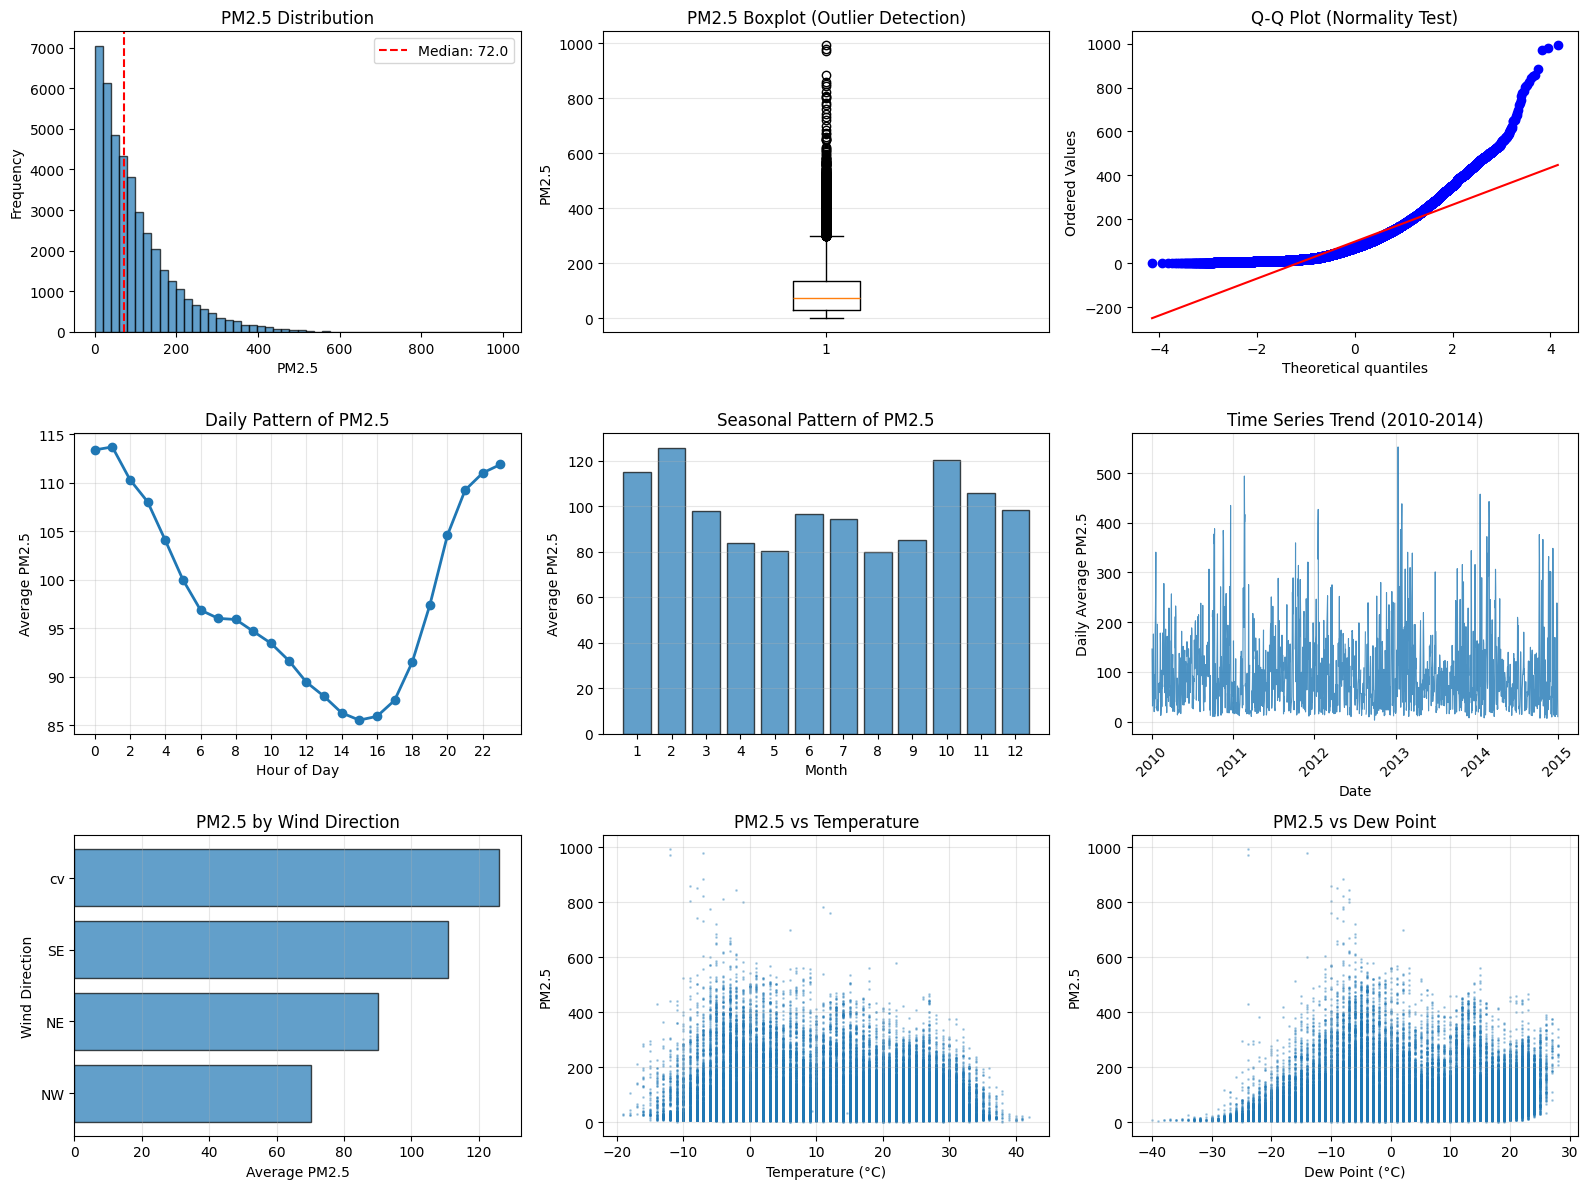

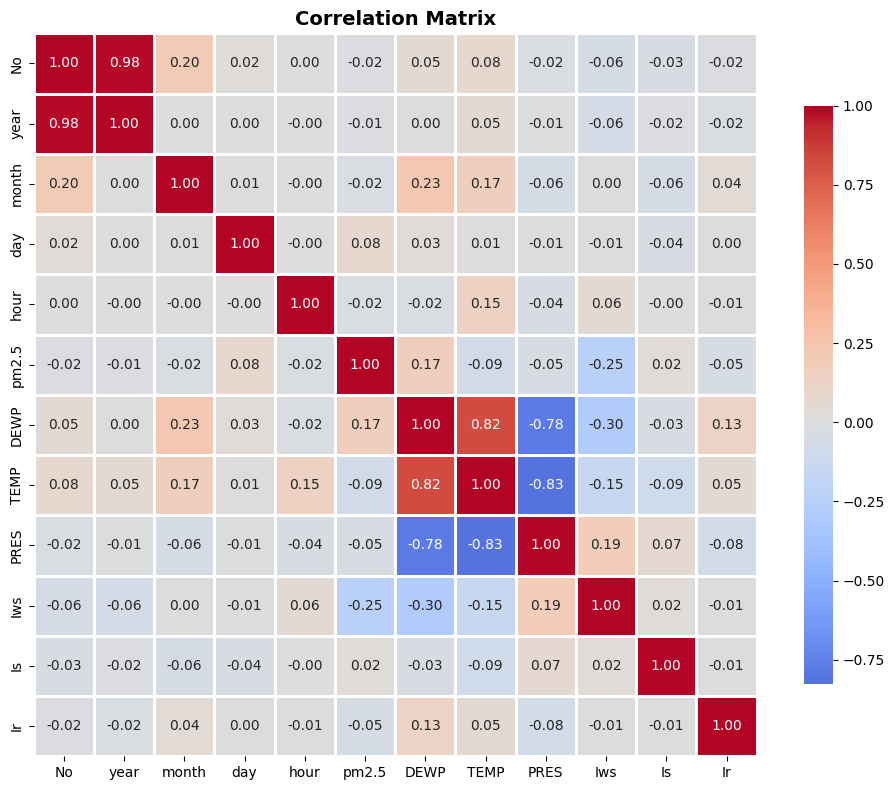



Outlier Analysis
Lower bound: -133.00
Upper bound: 299.00
Number of outliers: 1,773 (4.05%)
Max PM2.5 value: 994.00


Missing data temporal patterns
Missing values by year:
year
2010    669
2011    728
2012    489
2013     82
2014     99
Name: pm2.5, dtype: int64

First non-null PM2.5 index: 24
Last non-null PM2.5 index: 43823


key insights from eda
1. Target variable (PM2.5) has 2067 missing values (4.72%)
2. PM2.5 ranges from 0.0 to 994.0 with mean 98.6
3. Data shows positive skewness (1.80)
4. Strong temporal patterns exist (hourly and seasonal variations)
5. Wind direction and meteorological factors show correlation with PM2.5
6. Dataset spans 5 years with hourly measurements


In [9]:
plt.figure(figsize=(16, 12))

plt.subplot(3, 3, 1)
plt.hist(df['pm2.5'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.title('PM2.5 Distribution')
plt.axvline(df['pm2.5'].median(), color='red', linestyle='--', label=f'Median: {df["pm2.5"].median():.1f}')
plt.legend()

plt.subplot(3, 3, 2)
plt.boxplot(df['pm2.5'].dropna(), vert=True)
plt.ylabel('PM2.5')
plt.title('PM2.5 Boxplot (Outlier Detection)')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 3, 3)
stats.probplot(df['pm2.5'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Test)')

plt.subplot(3, 3, 4)
hourly_avg = df.groupby('hour')['pm2.5'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
plt.xlabel('Hour of Day')
plt.ylabel('Average PM2.5')
plt.title('Daily Pattern of PM2.5')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 2))

plt.subplot(3, 3, 5)
monthly_avg = df.groupby('month')['pm2.5'].mean()
plt.bar(monthly_avg.index, monthly_avg.values, edgecolor='black', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.title('Seasonal Pattern of PM2.5')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 3, 6)
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
daily_avg = df.groupby(df['date'].dt.date)['pm2.5'].mean()
plt.plot(daily_avg.index, daily_avg.values, linewidth=0.8, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Daily Average PM2.5')
plt.title('Time Series Trend (2010-2014)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 7)
wind_pm25 = df.groupby('cbwd')['pm2.5'].mean().sort_values()
plt.barh(wind_pm25.index, wind_pm25.values, edgecolor='black', alpha=0.7)
plt.xlabel('Average PM2.5')
plt.ylabel('Wind Direction')
plt.title('PM2.5 by Wind Direction')
plt.grid(axis='x', alpha=0.3)

plt.subplot(3, 3, 8)
plt.scatter(df['TEMP'], df['pm2.5'], alpha=0.3, s=1)
plt.xlabel('Temperature (°C)')
plt.ylabel('PM2.5')
plt.title('PM2.5 vs Temperature')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 9)
plt.scatter(df['DEWP'], df['pm2.5'], alpha=0.3, s=1)
plt.xlabel('Dew Point (°C)')
plt.ylabel('PM2.5')
plt.title('PM2.5 vs Dew Point')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n")
print("Outlier Analysis")
Q1 = df['pm2.5'].quantile(0.25)
Q3 = df['pm2.5'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['pm2.5'] < lower_bound) | (df['pm2.5'] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Max PM2.5 value: {df['pm2.5'].max():.2f}")

print("\n")
print("Missing data temporal patterns")
missing_by_year = df.groupby('year')['pm2.5'].apply(lambda x: x.isnull().sum())
print("Missing values by year:")
print(missing_by_year)
print(f"\nFirst non-null PM2.5 index: {df['pm2.5'].first_valid_index()}")
print(f"Last non-null PM2.5 index: {df['pm2.5'].last_valid_index()}")

print("\n")
print("key insights from eda")
print(f"1. Target variable (PM2.5) has {df['pm2.5'].isnull().sum()} missing values (4.72%)")
print(f"2. PM2.5 ranges from {df['pm2.5'].min():.1f} to {df['pm2.5'].max():.1f} with mean {df['pm2.5'].mean():.1f}")
print(f"3. Data shows {'positive' if df['pm2.5'].skew() > 0 else 'negative'} skewness ({df['pm2.5'].skew():.2f})")
print(f"4. Strong temporal patterns exist (hourly and seasonal variations)")
print(f"5. Wind direction and meteorological factors show correlation with PM2.5")
print(f"6. Dataset spans {df['year'].nunique()} years with hourly measurements")